# 🎬 Movie Dataset Analysis — Level 2

Deeper analysis of the 1980–2001 movie dataset across three exercises:
1. **Budget vs. financial & critical success**
2. **Reliability of directors and production companies**
3. **Genre, country, and audience trends over time**

---
## ⚙️ Setup: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

---
## 📂 Load & Clean Base Data

In [2]:
# Load the dataset
movies = pd.read_excel('movies_updated.xlsx')

# Fix the messy runtime column name
movies.rename(columns={'runtime,,': 'runtime'}, inplace=True)
movies['runtime'] = movies['runtime'].astype(str).str.replace(',', '').str.strip()
movies['runtime'] = pd.to_numeric(movies['runtime'], errors='coerce')

print(f'{len(movies):,} movies, {movies["year"].min()}–{movies["year"].max()}')
movies.head()

4,000 movies, 1980–2001


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344.0,Orion Pictures,98.0


---
# Exercise 1 — Does Bigger Budget Mean Bigger Success?

### Assumptions
- `ROI = (gross - budget) / budget` is undefined when `budget = 0`. **1,392 movies (35%) have `budget = 0`**, which almost certainly represents missing data rather than a real zero budget. These rows are treated as missing and dropped for any ROI-based analysis, in addition to dropping rows with missing `budget`, `gross`, or `score`.

## Task 1–2: Create ROI & Clean the Data

In [3]:
# Task 1: ROI feature
# Task 2: drop missing budget/gross/score (budget = 0 is treated as missing — see assumptions)
ex1 = movies.dropna(subset=['budget', 'gross', 'score']).copy()
ex1 = ex1[ex1['budget'] > 0]
ex1['ROI'] = (ex1['gross'] - ex1['budget']) / ex1['budget']

print(f'Rows before cleaning: {len(movies):,}')
print(f'Rows after cleaning:  {len(ex1):,}')
ex1['ROI'].describe()

Rows before cleaning: 4,000
Rows after cleaning:  2,559


count    2559.000000
mean        3.736646
std        82.297774
min        -0.999979
25%        -0.520625
50%         0.367533
75%         2.085190
max      4142.984983
Name: ROI, dtype: float64

## Task 3–5: Budget vs. Gross vs. Score vs. Votes (with Top-10 ROI Annotated)

,name,budget,gross,score,ROI
3459,The Blair Witch Project,60000,248639099.0,6.5,4142.984983
2093,El Mariachi,7000,2040920.0,6.9,290.560000
2467,Clerks,27000,3151130.0,7.7,115.708519
3233,In the Company of Men,25000,2804473.0,7.2,111.178920
209,E.T. the Extra-Terrestrial,10500000,792910554.0,7.8,74.515291
3089,The Full Monty,3500000,257938649.0,7.2,72.696757
5,Friday the 13th,550000,39754601.0,6.4,71.281093
2458,Four Weddings and a Funeral,4400000,245700832.0,7.1,54.841098
3291,Pi,60000,3221152.0,7.4,52.685867
1684,Slacker,23000,1228108.0,7.1,52.396000


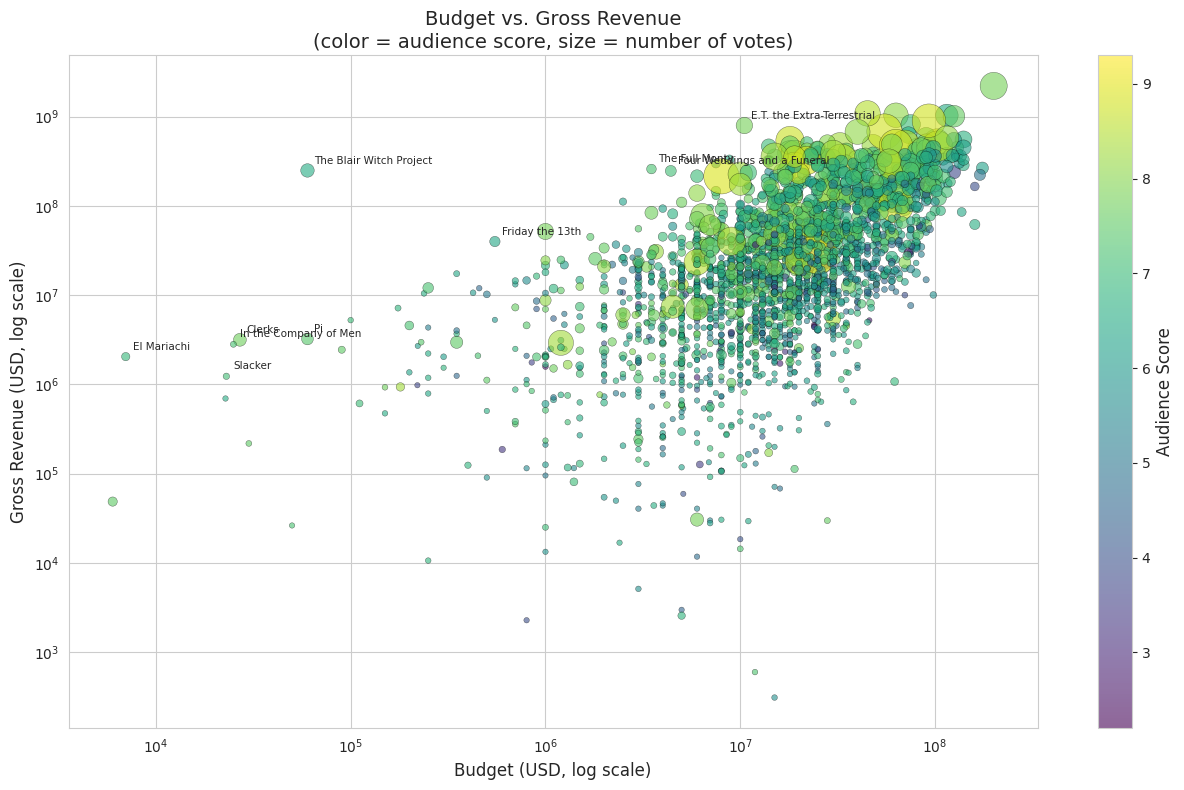

In [4]:
# Task 3-4: scatter of 4 variables at once (log scale for budget/gross since both are heavily right-skewed)
# Task 5: annotate the 10 highest-ROI movies
top10_roi = ex1.sort_values('ROI', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(13, 8))
sizes = (ex1['votes'] / ex1['votes'].max()) * 800 + 15
sc = ax.scatter(ex1['budget'], ex1['gross'], c=ex1['score'], s=sizes,
                cmap='viridis', alpha=0.6, edgecolor='k', linewidth=0.3)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Budget (USD, log scale)')
ax.set_ylabel('Gross Revenue (USD, log scale)')
ax.set_title('Budget vs. Gross Revenue\n(color = audience score, size = number of votes)')
cbar = plt.colorbar(sc, ax=ax); cbar.set_label('Audience Score')

for _, row in top10_roi.iterrows():
    ax.annotate(row['name'], (row['budget'], row['gross']), fontsize=7.5,
                xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('ex1_budget_gross_scatter.png', bbox_inches='tight')
plt.show()

top10_roi[['name', 'budget', 'gross', 'score', 'ROI']]

## Task 6: ROI Distribution Across the Top 10 Genres

genre
Animation    1.391979
Horror       1.245093
Fantasy      1.060715
Action       0.578256
Comedy       0.367100
Biography    0.261958
Mystery      0.160255
Adventure    0.096643
Drama        0.052628
Crime       -0.055319
Name: ROI, dtype: float64

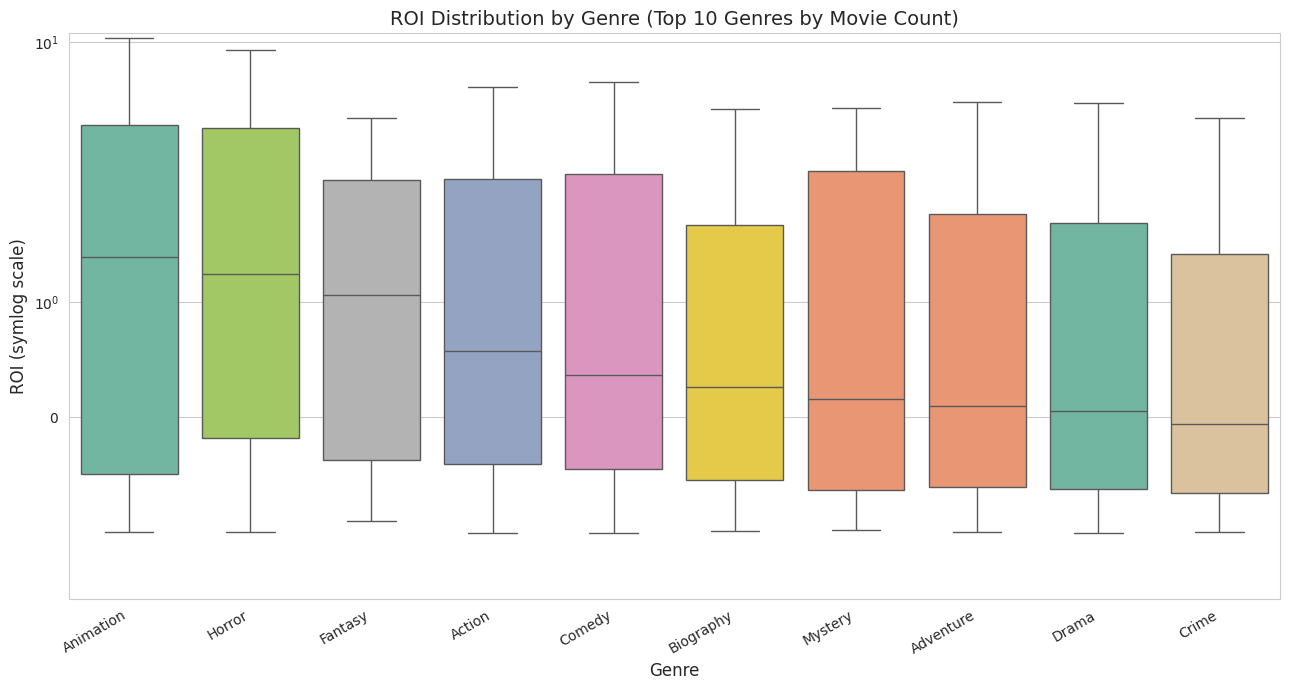

In [5]:
top10_genres = movies['genre'].value_counts().head(10).index
ex1_top = ex1[ex1['genre'].isin(top10_genres)].copy()
order = ex1_top.groupby('genre')['ROI'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 7))
sns.boxplot(data=ex1_top, x='genre', y='ROI', order=order, hue='genre',
            legend=False, ax=ax, showfliers=False, palette='Set2')
ax.set_yscale('symlog')
ax.set_title('ROI Distribution by Genre (Top 10 Genres by Movie Count)')
ax.set_xlabel('Genre'); ax.set_ylabel('ROI (symlog scale)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('ex1_genre_roi_boxplot.png', bbox_inches='tight')
plt.show()

ex1_top.groupby('genre')['ROI'].median().sort_values(ascending=False)

## Task 7: Answers

In [6]:
# Grounding numbers for the written answers below
print('Correlation budget vs gross :', round(ex1['budget'].corr(ex1['gross']), 3))
print('Correlation score  vs ROI   :', round(ex1['score'].corr(ex1['ROI']), 3))
print()
print('High score, terrible ROI example:')
print(ex1[ex1['score'] >= 7.5].sort_values('ROI').head(3)[['name', 'score', 'ROI']].to_string(index=False))
print()
print('Low score, huge ROI example:')
print(ex1[ex1['score'] < 6].sort_values('ROI', ascending=False).head(3)[['name', 'score', 'ROI']].to_string(index=False))

Correlation budget vs gross : 0.548
Correlation score  vs ROI   : 0.02

High score, terrible ROI example:
                    name  score       ROI
The Lovers on the Bridge    7.6 -0.998940
     The Boondock Saints    7.8 -0.994922
             Underground    8.1 -0.987780

Low score, huge ROI example:
              name  score       ROI
Look Who's Talking    5.9 38.599975
      Deathstalker    4.6 25.081510
            Cyborg    5.1 19.332918


### ✅ Task 7 Answers
1. **Do larger budgets generally result in higher revenue?** Yes, moderately. Budget and gross revenue have a **positive correlation of ~0.55** — bigger budgets tend to buy bigger box-office numbers, but the relationship is far from one-to-one; plenty of high-budget films underperform and plenty of micro-budget films (e.g. *The Blair Witch Project*, *El Mariachi*) far outperform.
2. **Which genre generates the highest returns relative to investment?** **Animation**, followed closely by **Horror** — both have the highest median ROI among the top-10 genres. These genres are historically cheap to produce relative to the audience they reach, which inflates ROI.
3. **Are highly rated movies always financially successful?** **No.** The correlation between score and ROI is essentially **zero (~0.02)**. Several critically liked films (score ≥ 7.5) posted near-total losses, while several poorly rated films (score < 6) returned 15–38× their budget. Critical reception and financial return are largely independent in this dataset.

---
# Exercise 2 — Reliable Directors & Production Companies

### Assumptions
- 16 movies list `director = "Directors"` (a generic placeholder, mostly multi-director/anthology films like *Twilight Zone: The Movie*). This is treated as missing/invalid director data and excluded from the director analysis only.
- For company ROI, the same budget/gross/score cleaning from Exercise 1 (`ex1`) is reused, since ROI is undefined for `budget = 0`.

## Task 1–2: Director Statistics (≥5 Movies)

In [7]:
movies_d = movies[movies['director'] != 'Directors']

dir_stats = movies_d.groupby('director').agg(
    n_movies=('name', 'count'),
    avg_score=('score', 'mean'),
    median_score=('score', 'median'),
    std_score=('score', 'std')
).reset_index()
dir_stats = dir_stats[dir_stats['n_movies'] >= 5].fillna({'std_score': 0})

print(f'{len(dir_stats)} directors qualify with ≥5 movies')
dir_stats.sort_values('avg_score', ascending=False).head(10)

215 directors qualify with ≥5 movies


,director,n_movies,avg_score,median_score,std_score
428,Emir Kusturica,5,7.900000,8.10,0.367423
656,James Cameron,6,7.883333,7.90,0.487511
545,Giuseppe Tornatore,6,7.816667,7.70,0.411906
1506,Steven Spielberg,14,7.664286,7.75,0.749982
767,Joel Coen,9,7.655556,7.70,0.308671
1124,Mike Leigh,5,7.620000,7.50,0.268328
741,Jim Jarmusch,6,7.600000,7.60,0.089443
875,Kar-Wai Wong,6,7.583333,7.60,0.475044
1031,Martin Scorsese,11,7.581818,7.50,0.599697
1369,Robert Zemeckis,10,7.560000,7.60,0.735149


## Task 3: Visualizing Director Reliability

,director,n_movies,avg_score,std_score
741,Jim Jarmusch,6,7.600000,0.089443
1124,Mike Leigh,5,7.620000,0.268328
767,Joel Coen,9,7.655556,0.308671


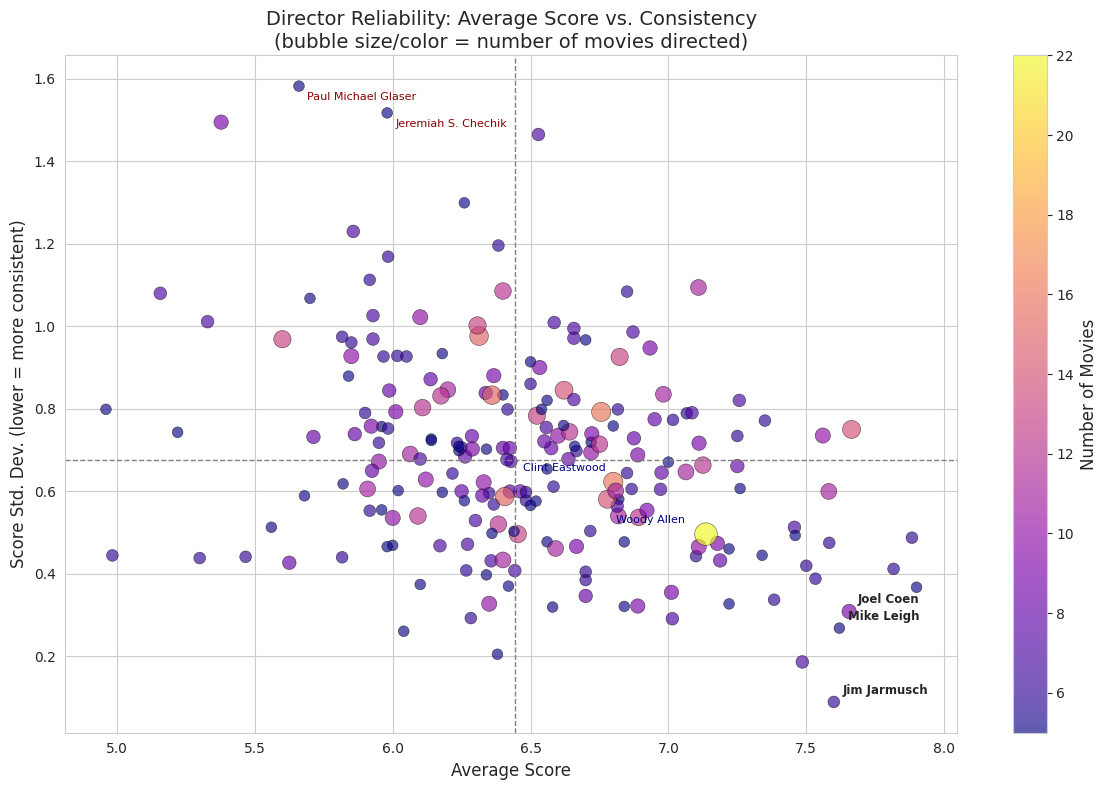

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))
sizes = dir_stats['n_movies'] * 12
sc = ax.scatter(dir_stats['avg_score'], dir_stats['std_score'], s=sizes, c=dir_stats['n_movies'],
                 cmap='plasma', alpha=0.65, edgecolor='k', linewidth=0.4)
ax.axvline(dir_stats['avg_score'].median(), color='gray', linestyle='--', linewidth=1)
ax.axhline(dir_stats['std_score'].median(), color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Average Score')
ax.set_ylabel('Score Std. Dev. (lower = more consistent)')
ax.set_title('Director Reliability: Average Score vs. Consistency\n(bubble size/color = number of movies directed)')
cbar = plt.colorbar(sc, ax=ax); cbar.set_label('Number of Movies')

# Rank by a combined score+consistency rank to find the most reliable directors
dir_stats['rank_score'] = dir_stats['avg_score'].rank(ascending=False)
dir_stats['rank_consistency'] = dir_stats['std_score'].rank(ascending=True)
dir_stats['combined_rank'] = dir_stats['rank_score'] + dir_stats['rank_consistency']
most_reliable = dir_stats.sort_values('combined_rank').head(3)
for _, r in most_reliable.iterrows():
    ax.annotate(r['director'], (r['avg_score'], r['std_score']), fontsize=8.5, fontweight='bold',
                xytext=(6, 6), textcoords='offset points')

most_inconsistent = dir_stats.sort_values('std_score', ascending=False).head(2)
for _, r in most_inconsistent.iterrows():
    ax.annotate(r['director'], (r['avg_score'], r['std_score']), fontsize=8, color='darkred',
                xytext=(6, -10), textcoords='offset points')

most_productive = dir_stats.sort_values('n_movies', ascending=False).head(2)
for _, r in most_productive.iterrows():
    ax.annotate(r['director'], (r['avg_score'], r['std_score']), fontsize=8, color='navy',
                xytext=(-65, 8), textcoords='offset points')

plt.tight_layout()
plt.savefig('ex2_director_reliability.png', bbox_inches='tight')
plt.show()

most_reliable[['director', 'n_movies', 'avg_score', 'std_score']]

## Task 4–5: Production Company Statistics (≥20 Movies) — All 4 Metrics At Once

18 companies qualify with ≥20 movies


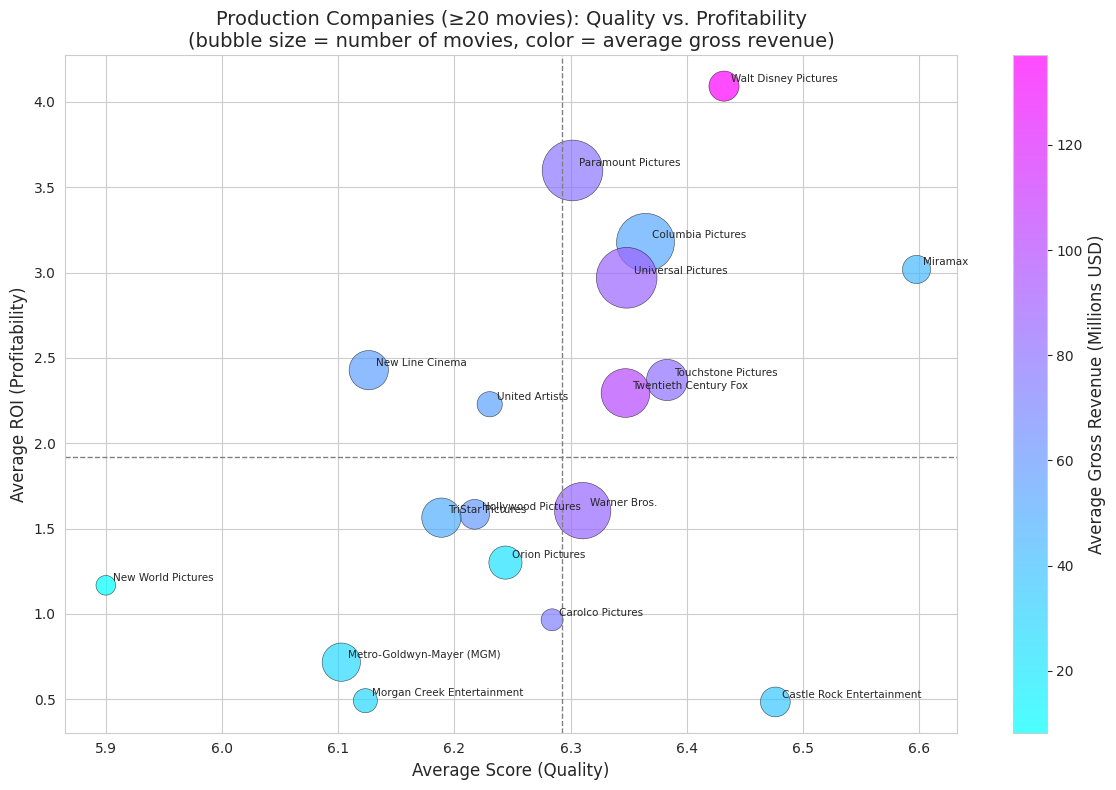

In [9]:
comp_stats = movies.groupby('company').agg(
    n_movies=('name', 'count'),
    avg_gross=('gross', 'mean'),
    avg_score=('score', 'mean')
).reset_index()
comp_roi = ex1.groupby('company')['ROI'].mean().reset_index().rename(columns={'ROI': 'avg_roi'})
comp_stats = comp_stats.merge(comp_roi, on='company', how='left')
comp_stats = comp_stats[comp_stats['n_movies'] >= 20].dropna(subset=['avg_roi'])

print(f'{len(comp_stats)} companies qualify with ≥20 movies')

fig, ax = plt.subplots(figsize=(12, 8))
sizes = comp_stats['n_movies'] * 10
sc = ax.scatter(comp_stats['avg_score'], comp_stats['avg_roi'], s=sizes, c=comp_stats['avg_gross'] / 1e6,
                 cmap='cool', alpha=0.7, edgecolor='k', linewidth=0.4)
for _, r in comp_stats.iterrows():
    ax.annotate(r['company'], (r['avg_score'], r['avg_roi']), fontsize=7.5, xytext=(5, 3), textcoords='offset points')
med_score, med_roi = comp_stats['avg_score'].median(), comp_stats['avg_roi'].median()
ax.axhline(med_roi, color='gray', linestyle='--', linewidth=1)
ax.axvline(med_score, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Average Score (Quality)')
ax.set_ylabel('Average ROI (Profitability)')
ax.set_title('Production Companies (≥20 movies): Quality vs. Profitability\n'
             '(bubble size = number of movies, color = average gross revenue)')
cbar = plt.colorbar(sc, ax=ax); cbar.set_label('Average Gross Revenue (Millions USD)')
plt.tight_layout()
plt.savefig('ex2_company_quality_vs_profit.png', bbox_inches='tight')
plt.show()

## Task 6: Answers

In [10]:
quality_over_profit = comp_stats[(comp_stats['avg_score'] >= med_score) & (comp_stats['avg_roi'] < med_roi)]\
    .sort_values('avg_score', ascending=False)
profit_over_quality = comp_stats[(comp_stats['avg_score'] < med_score) & (comp_stats['avg_roi'] >= med_roi)]\
    .sort_values('avg_roi', ascending=False)

print('Quality-over-profitability companies (above-median score, below-median ROI):')
print(quality_over_profit[['company', 'avg_score', 'avg_roi', 'n_movies']].to_string(index=False))
print()
print('Profitability-over-quality companies (below-median score, above-median ROI):')
print(profit_over_quality[['company', 'avg_score', 'avg_roi', 'n_movies']].to_string(index=False))

Quality-over-profitability companies (above-median score, below-median ROI):
                  company  avg_score  avg_roi  n_movies
Castle Rock Entertainment   6.476087 0.484668        46
             Warner Bros.   6.310303 1.605360       165

Profitability-over-quality companies (below-median score, above-median ROI):
        company  avg_score  avg_roi  n_movies
New Line Cinema   6.126250 2.428622        80
 United Artists   6.230303 2.228752        33


### ✅ Task 6 Answers
1. **Three consistently successful directors:** **Jim Jarmusch**, **Mike Leigh**, and **Joel Coen** rank best on a combined score-and-consistency measure — high average scores (7.6+) paired with very low score variance, meaning their quality rarely dips. (Honorable mention: **Woody Allen**, who combines a strong average score with the highest output of any director at ≥5 movies — 22 films.)
2. **Companies that prioritize quality over profitability:** **Castle Rock Entertainment** and **Warner Bros.** sit above the median score but below the median ROI — solid critical output without translating into top-tier returns.
3. **Companies that prioritize profitability over quality:** **New Line Cinema** and **United Artists** sit below the median score but above the median ROI — strong financial returns despite more middling average reception.

---
# Exercise 3 — Trends Across Time, Genre, and Country

### Assumptions
- The dataset spans **1980–2001** (22 years), so the "2000s" decade bucket below only contains **2 years (2000–2001)** of data, not a full 10 years. Raw movie counts for the 2000s would therefore look artificially low purely from the shorter window — genre trends are shown as a **% share within each decade** rather than raw counts, to keep decades comparable.
- `median(votes)` for the Hidden Gem definition is computed **once, globally**, across all 4,000 movies.

## Task 1–2: Decade & Genre Statistics

In [11]:
# Task 1: decade groups
movies['decade'] = (movies['year'] // 10) * 10

# Task 2: per decade & genre — count, avg score, total gross
decade_genre = movies.groupby(['decade', 'genre']).agg(
    n_movies=('name', 'count'),
    avg_score=('score', 'mean'),
    total_gross=('gross', 'sum')
).reset_index()

print(movies['decade'].value_counts().sort_index().rename('movies per decade'))
decade_genre.sort_values(['decade', 'n_movies'], ascending=[True, False]).head(10)

decade
1980    1643
1990    2000
2000     357
Name: movies per decade, dtype: int64


,decade,genre,n_movies,avg_score,total_gross
4,1980,Comedy,565,6.090619,1.155346e+10
0,1980,Action,320,5.969688,1.164296e+10
6,1980,Drama,312,6.510256,4.743267e+09
1,1980,Adventure,105,6.194286,2.819619e+09
5,1980,Crime,99,6.497980,1.301625e+09
10,1980,Horror,95,5.808421,1.020685e+09
3,1980,Biography,66,6.934848,1.360413e+09
2,1980,Animation,37,6.981081,1.084387e+09
8,1980,Fantasy,16,6.168750,2.983655e+08
15,1980,Thriller,10,5.840000,3.868978e+07


## Task 3: Genre Popularity Across Decades

genre
Drama        3.654225
Crime        2.285802
Biography    0.485446
Action      -0.006371
Adventure   -2.796093
Comedy      -3.623008
Name: share change, 1980s → 2000s (pp), dtype: float64

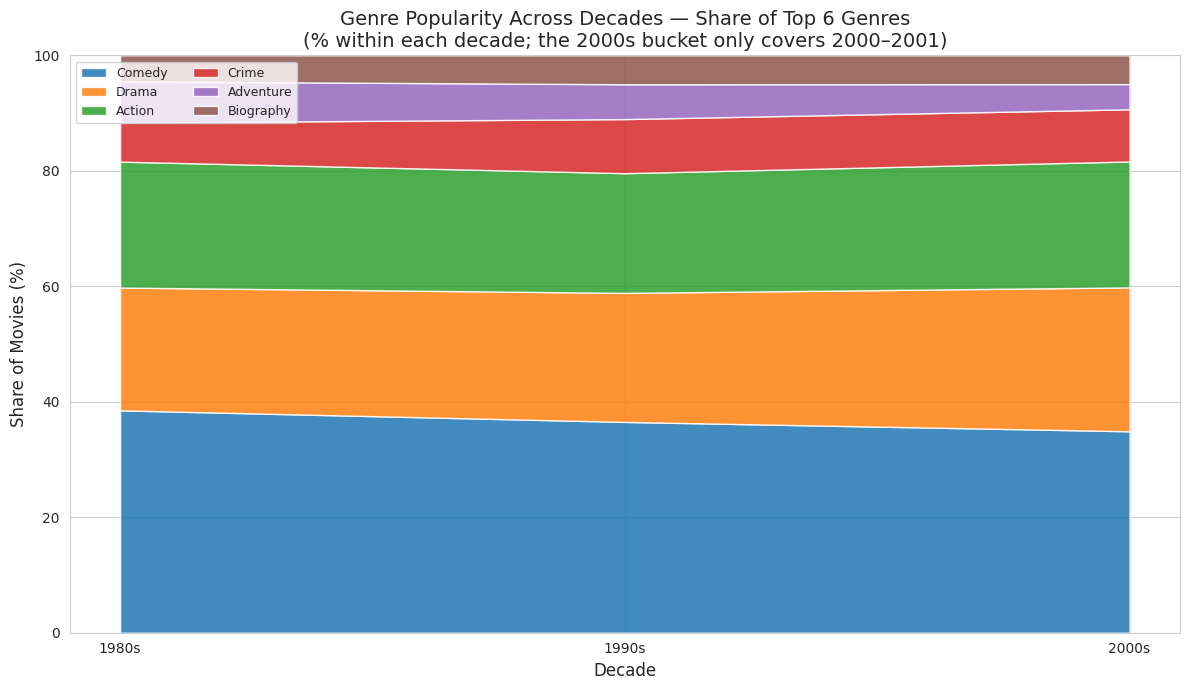

In [12]:
top_genres = movies['genre'].value_counts().head(6).index.tolist()
pivot = decade_genre[decade_genre['genre'].isin(top_genres)].pivot(index='decade', columns='genre', values='n_movies').fillna(0)
pivot = pivot[top_genres]
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 7))
ax.stackplot(pivot_pct.index, [pivot_pct[g] for g in top_genres], labels=top_genres, alpha=0.85)
ax.set_xlabel('Decade'); ax.set_ylabel('Share of Movies (%)')
ax.set_title('Genre Popularity Across Decades — Share of Top 6 Genres\n'
             '(% within each decade; the 2000s bucket only covers 2000–2001)')
ax.set_xticks(pivot_pct.index); ax.set_xticklabels([f'{d}s' for d in pivot_pct.index])
ax.set_ylim(0, 100)
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('ex3_genre_decade_share.png', bbox_inches='tight')
plt.show()

(pivot_pct.loc[2000] - pivot_pct.loc[1980]).sort_values(ascending=False).rename('share change, 1980s → 2000s (pp)')

## Task 4–6: Country Comparison (≥30 Movies)

,avg_score,avg_budget,score_per_million_budget
country,,,
Italy,6.611111,3.406667e+06,1.940639
Canada,6.030000,6.092006e+06,0.989822
France,6.798000,8.513333e+06,0.798512
Australia,6.660377,9.016038e+06,0.738726
Japan,7.108889,1.051778e+07,0.675893
United Kingdom,6.555808,1.033168e+07,0.634535
United States,6.200942,1.764754e+07,0.351377
Germany,6.560465,2.675581e+07,0.245198


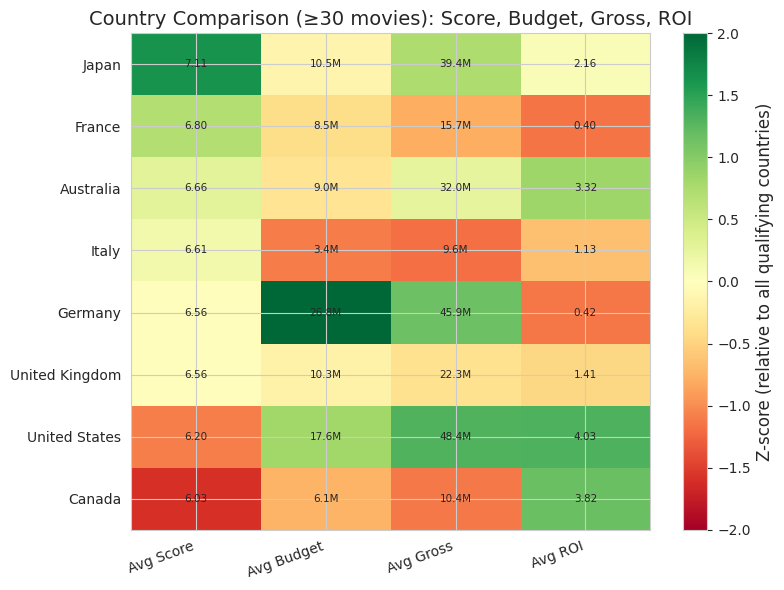

In [13]:
# Task 4: countries with at least 30 movies
country_counts = movies['country'].value_counts()
valid_countries = country_counts[country_counts >= 30].index

# Task 5: per-country metrics
country_stats = movies[movies['country'].isin(valid_countries)].groupby('country').agg(
    avg_score=('score', 'mean'),
    avg_budget=('budget', 'mean'),
    avg_gross=('gross', 'mean')
).reset_index()
country_roi = ex1[ex1['country'].isin(valid_countries)].groupby('country')['ROI'].mean()\
    .reset_index().rename(columns={'ROI': 'avg_roi'})
country_stats = country_stats.merge(country_roi, on='country', how='left').set_index('country')

# Task 6: single visualization, all 4 metrics — z-score heatmap with real values annotated
z = (country_stats - country_stats.mean()) / country_stats.std()
z = z.sort_values('avg_score', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(z.values, cmap='RdYlGn', aspect='auto', vmin=-2, vmax=2)
ax.set_xticks(range(len(z.columns)))
ax.set_xticklabels(['Avg Score', 'Avg Budget', 'Avg Gross', 'Avg ROI'], rotation=20, ha='right')
ax.set_yticks(range(len(z.index))); ax.set_yticklabels(z.index)
for i in range(len(z.index)):
    for j, col in enumerate(country_stats.columns):
        val = country_stats.loc[z.index[i], col]
        label = f'{val:,.2f}' if col in ('avg_score', 'avg_roi') else f'{val/1e6:,.1f}M'
        ax.text(j, i, label, ha='center', va='center', fontsize=7.5)
cbar = plt.colorbar(im, ax=ax); cbar.set_label('Z-score (relative to all qualifying countries)')
ax.set_title('Country Comparison (≥30 movies): Score, Budget, Gross, ROI')
plt.tight_layout()
plt.savefig('ex3_country_heatmap.png', bbox_inches='tight')
plt.show()

country_stats['score_per_million_budget'] = country_stats['avg_score'] / (country_stats['avg_budget'] / 1e6)
country_stats.sort_values('score_per_million_budget', ascending=False)[['avg_score', 'avg_budget', 'score_per_million_budget']]

## Task 7–9: Hidden Gems

Global median votes: 13,000
Total hidden gems found: 5 out of 4,000 movies


,name,year,genre,country,score,votes
474,The Business of Show Business,1983,History,Canada,8.3,79
573,Repentance,1984,Drama,Soviet Union,8.3,4100
66,Moscow Does Not Believe in Tears,1980,Comedy,Soviet Union,8.1,12000
724,Mishima: A Life in Four Chapters,1985,Biography,United States,8.0,10000
1370,Salaam Bombay!,1988,Crime,United States,8.0,8800


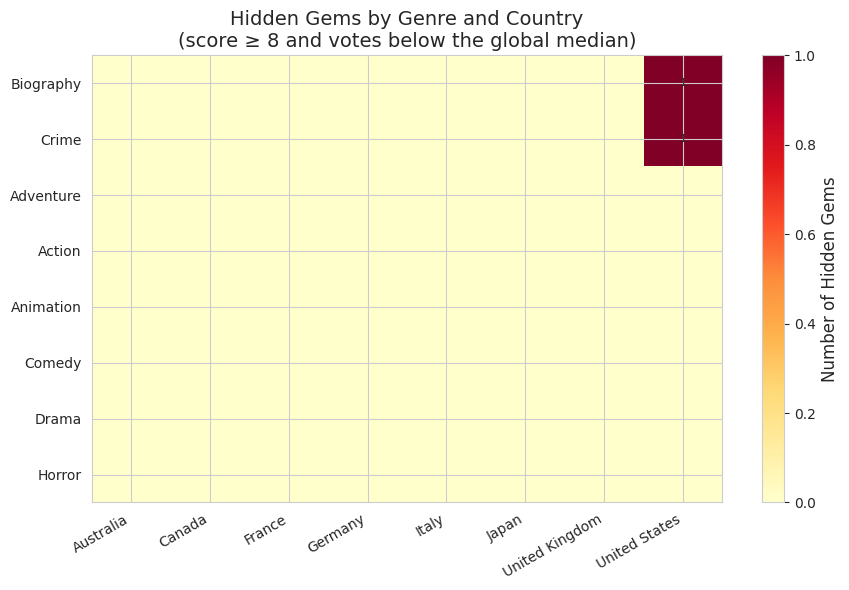

In [14]:
# Task 7: Hidden Gem definition
median_votes = movies['votes'].median()
movies['hidden_gem'] = (movies['score'] >= 8) & (movies['votes'] < median_votes)
print(f'Global median votes: {median_votes:,.0f}')
print(f'Total hidden gems found: {movies["hidden_gem"].sum()} out of {len(movies):,} movies')

# Task 8: count by genre and country (restricted to genres/countries with reasonable sample sizes)
top8_genres = movies['genre'].value_counts().head(8).index
gem_counts = movies[movies['genre'].isin(top8_genres) & movies['country'].isin(valid_countries)]\
    .groupby(['genre', 'country'])['hidden_gem'].sum().reset_index()
gem_pivot = gem_counts.pivot(index='genre', columns='country', values='hidden_gem').fillna(0)
gem_pivot = gem_pivot.loc[gem_pivot.sum(axis=1).sort_values(ascending=False).index]

# Task 9: visualization
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(gem_pivot.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(gem_pivot.columns))); ax.set_xticklabels(gem_pivot.columns, rotation=30, ha='right')
ax.set_yticks(range(len(gem_pivot.index))); ax.set_yticklabels(gem_pivot.index)
for i in range(len(gem_pivot.index)):
    for j in range(len(gem_pivot.columns)):
        v = int(gem_pivot.values[i, j])
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center', fontsize=8)
cbar = plt.colorbar(im, ax=ax); cbar.set_label('Number of Hidden Gems')
ax.set_title('Hidden Gems by Genre and Country\n(score ≥ 8 and votes below the global median)')
plt.tight_layout()
plt.savefig('ex3_hidden_gems.png', bbox_inches='tight')
plt.show()

movies[movies['hidden_gem']][['name', 'year', 'genre', 'country', 'score', 'votes']].sort_values('score', ascending=False)

## Task 10: Answers

### ✅ Task 10 Answers
1. **Which genres gained popularity over time?** Looking at share-of-movies-per-decade (not raw counts, since the 2000s bucket is only 2 years): **Drama** (+3.7 percentage points from the 1980s to the 2000s) and **Crime** (+2.3pp) grew the most, while **Comedy** (-3.6pp) and **Adventure** (-2.8pp) lost the most ground. Comedy still remains the single largest genre throughout, but its dominance is gradually shrinking.
2. **Which countries produce the highest-quality movies relative to budget?** **Italy** delivers by far the best score-per-budget-dollar ratio, followed by **Canada** and **France** — all achieve solid average scores (6.0–6.8) on comparatively small budgets (under $9M average). The **United States** and **Germany** sit at the bottom of this ratio: their movies cost the most on average but don't return proportionally higher scores. Note **Japan** has the single highest average score (7.1) of any qualifying country, just on a moderate budget.
3. **Which genre/country combinations are most underrated by audiences?** Only **5 movies** in the entire dataset meet the strict Hidden Gem bar (score ≥ 8 *and* votes below the global median) — which itself is a finding: highly rated films in this dataset are almost always also widely seen. The few hidden gems that do exist skew heavily **international/non-English** — e.g. a Soviet drama (*Repentance*), a Russian romance (*Moscow Does Not Believe in Tears*), a Japanese biographical film (*Mishima*), and an Indian drama (*Salaam Bombay!*) — suggesting foreign-language critical successes are the genre/country combination most likely to be overlooked by the broader (English-speaking) audience captured in this dataset.

---
## 📝 Final Storytelling Report

> *As a data analyst presenting a deeper-dive analysis of the 1980–2001 movie dataset:*
>
> **Budget and success.** Spending more generally buys more revenue — budget and gross are moderately correlated (r ≈ 0.55) — but it buys neither guaranteed profitability nor critical acclaim: score and ROI are essentially uncorrelated (r ≈ 0.02). Animation and Horror deliver the best returns relative to investment, largely because they are cheap to produce. A handful of micro-budget outliers (*The Blair Witch Project*, *El Mariachi*) dwarf every big-budget film on a pure ROI basis.
>
> **People and companies you can rely on.** A small set of directors — Jim Jarmusch, Mike Leigh, Joel Coen, and Woody Allen — combine high average scores with low variance, making them the safest creative bets in the dataset. Among major studios, Warner Bros. and Castle Rock Entertainment lean toward quality over box-office return, while New Line Cinema and United Artists lean the opposite way, prioritizing profitability over critical performance.
>
> **Trends over time and geography.** Comedy remains the most-produced genre throughout, but its share is slowly declining as Drama and Crime gain ground. Italy, Canada, and France punch well above their weight, producing solidly-rated films on modest budgets, while the U.S. and Germany spend the most per film without a proportional quality payoff. True "hidden gems" — high score, low visibility — are rare, and the ones that exist are overwhelmingly international films that never broke through to a mass English-speaking audience.
>
> **Recommendations for the studio:** Back directors with a proven low-variance track record (Coen, Jarmusch, Allen) for consistent quality. For pure financial upside, favor low-budget Animation/Horror concepts over big-budget bets. Consider co-productions or acquisitions in Italy, Canada, and France, where quality-per-dollar is highest, and actively scout acclaimed foreign-language titles — this dataset suggests they are the most under-distributed category of genuinely good films.